# Fake Job Posting Detection

### Machine Learning & NLP Internship Project

## Project Introduction

Fake job advertisements are an increasing concern for job seekers and online employment platforms. Fraudulent postings may contain misleading job descriptions, unrealistic salary claims, fake company information, or requests for money and personal information.

This project develops a machine learning-based system for identifying potentially fraudulent job postings using Natural Language Processing (NLP) and classification algorithms.

The project analyzes job-related textual information such as job title, company profile, description, requirements, and benefits. TF-IDF is used to transform textual information into numerical features, followed by the application and comparison of multiple machine learning algorithms.

The final model is integrated into a Flask-based web application called **JobGuard AI**, allowing users to enter a job posting and receive an automated prediction.

> **Disclaimer:** The prediction generated by this system is a machine-learning result and should not be considered definitive evidence that a job posting is fraudulent or legitimate.

## Problem Statement

The objective of this project is to develop a machine learning system capable of classifying job postings as legitimate or fraudulent.

The system should:

- Analyze job-posting data.
- Handle missing and inconsistent information.
- Explore patterns in fraudulent and legitimate postings.
- Process textual job information.
- Convert text into numerical features using TF-IDF.
- Train multiple classification models.
- Compare models using appropriate evaluation metrics.
- Select the most suitable model.
- Deploy the final model through a Flask web application.

## Objectives

1. Explore and understand the fake job posting dataset.
2. Analyze missing values and important feature distributions.
3. Perform text preprocessing and feature engineering.
4. Combine relevant textual attributes.
5. Apply TF-IDF vectorization with unigram and bigram features.
6. Train multiple machine learning classification algorithms.
7. Evaluate models using accuracy, precision, recall and F1 score.
8. Compare raw and cleaned text performance.
9. Analyze different feature combinations.
10. Select and save the best-performing model.
11. Build a functional Flask-based prediction system.
12. Provide useful risk information and recommendations to users.

# ===================================
# Fake Job Posting Detection Project
# Internship Project
# ===================================

#### 1. Import Libraries

In [184]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

%matplotlib inline

### 2. Load Dataset

In [186]:
df = pd.read_csv("../data/fake_job_postings.csv")

### 3. Dataset Overview

In [185]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,fraudulent,combined_text,text_length,cleaned_text,cleaned_length,title_description,title_requirements,description_requirements,title_description_requirements,all_features
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,...,0,"Marketing Intern We're Food52, and we've creat...",2662,marketing intern we re food52 and we ve create...,2003,"Marketing Intern Food52, a fast-growing, James...",Marketing Intern Experience with content manag...,"Food52, a fast-growing, James Beard Award-winn...","Marketing Intern Food52, a fast-growing, James...","Marketing Intern We're Food52, and we've creat..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,...,0,Customer Service - Cloud Video Production 90 S...,6133,customer service cloud video production 90 sec...,4082,Customer Service - Cloud Video Production Orga...,Customer Service - Cloud Video Production What...,Organised - Focused - Vibrant - Awesome!Do you...,Customer Service - Cloud Video Production Orga...,Customer Service - Cloud Video Production 90 S...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,...,0,Commissioning Machinery Assistant (CMA) Valor ...,2640,commissioning machinery assistant cma valor se...,1994,Commissioning Machinery Assistant (CMA) Our cl...,Commissioning Machinery Assistant (CMA) Implem...,"Our client, located in Houston, is actively se...",Commissioning Machinery Assistant (CMA) Our cl...,Commissioning Machinery Assistant (CMA) Valor ...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,...,0,Account Executive - Washington DC Our passion ...,5462,account executive washington dc our passion fo...,4433,Account Executive - Washington DC THE COMPANY:...,Account Executive - Washington DC EDUCATION: B...,THE COMPANY: ESRI – Environmental Systems Rese...,Account Executive - Washington DC THE COMPANY:...,Account Executive - Washington DC Our passion ...
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,...,0,Bill Review Manager SpotSource Solutions LLC i...,3949,bill review manager spotsource solutions llc i...,3207,Bill Review Manager JOB TITLE: Itemization Rev...,Bill Review Manager QUALIFICATIONS:RN license ...,JOB TITLE: Itemization Review ManagerLOCATION:...,Bill Review Manager JOB TITLE: Itemization Rev...,Bill Review Manager SpotSource Solutions LLC i...


In [44]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (17880, 18)


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [46]:
df.describe(include='all')

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


In [47]:
df.sample(5)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
5838,5839,UST Testing Technician III,"US, CA, Bakersfield, CA",Oil & Energy,70000-80000,Jaco Oil and Refined Resources have partnered ...,Qualified candidates are encouraged to apply d...,Responsibilities &amp; Position Requirements:T...,Competitive compensation package including bas...,0,1,1,Full-time,Mid-Senior level,Certification,Oil & Energy,Other,1
87,88,Customer Service Associate - On Call,"US, TN, Franklin",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based ...,Required Qualifications:High school diploma or...,NaN,0,1,0,Full-time,Entry level,High School or equivalent,Insurance,Customer Service,0
1643,1644,iOS Engineer,"US, NY, New York",Product Team,NaN,"We're Food52, and we've created a groundbreaki...","Food52, the James Beard Award-winning online f...","Strong engineering background in algorithms, d...",NaN,0,1,1,NaN,NaN,NaN,NaN,NaN,0
10998,10999,Online Marketing Manager,"IL, TA,",Marketing,NaN,PowToon (#URL_84da40102d63eebf414f1476e73cf04c...,PowToon was named one of Israel’s HOTTEST Star...,ESSENTIAL EXPERIENCE &amp; SKILL SET PRE-REQUI...,NaN,0,1,1,Full-time,Entry level,Bachelor's Degree,Internet,Marketing,0
3010,3011,Lead Recruiter,"US, CA, San Francisco",NaN,NaN,Intercom (#URL_cb674f93cbcd215a3a0a57a8615a565...,About UsIntercom (#URL_20af2fe8ac053b6b00899f5...,"Among other requirements, we'd love our Lead R...","Benefits include a competitive salary, stock o...",0,1,1,Full-time,Director,Bachelor's Degree,Internet,Human Resources,0


### 4. Missing Values Analysis

In [187]:
missing_values = df.isnull().sum()

missing_values

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [49]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


### 5. Missing Values Visualization

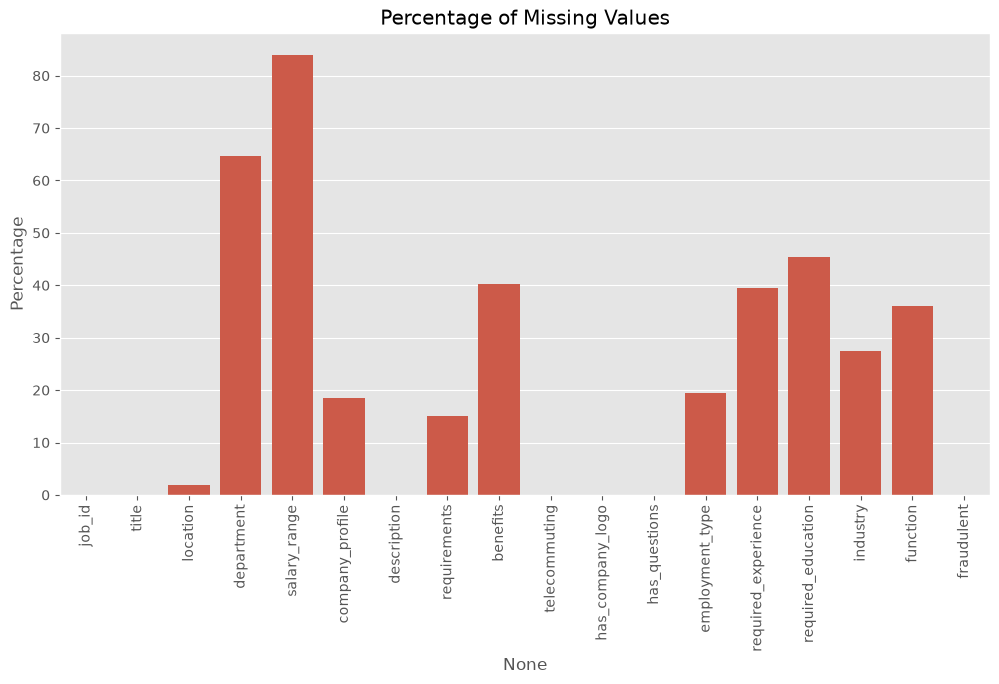

In [188]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Percentage"]
)

plt.xticks(rotation=90)
plt.title("Percentage of Missing Values")

plt.show()

### 6. Class Distribution

In [51]:
# Count real and fake job postings
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [52]:
# Percentage distribution
round(df['fraudulent'].value_counts(normalize=True) * 100, 2)

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

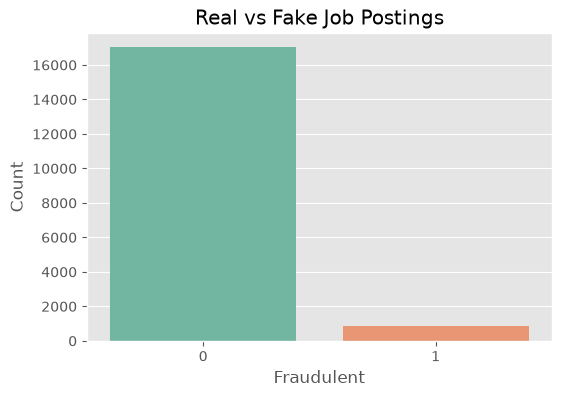

In [189]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='fraudulent',
    data=df,
    palette='Set2'
)

plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

### 7. Duplicate Records

In [54]:
# Total duplicate rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### 8. Unique Values Analysis

In [190]:
for column in df.columns:
    print(f"\n{column}")
    print("-"*40)
    print(df[column].nunique())


job_id
----------------------------------------
17880

title
----------------------------------------
11231

location
----------------------------------------
3105

department
----------------------------------------
1337

salary_range
----------------------------------------
874

company_profile
----------------------------------------
1709

description
----------------------------------------
14801

requirements
----------------------------------------
11967

benefits
----------------------------------------
6204

telecommuting
----------------------------------------
2

has_company_logo
----------------------------------------
2

has_questions
----------------------------------------
2

employment_type
----------------------------------------
5

required_experience
----------------------------------------
7

required_education
----------------------------------------
13

industry
----------------------------------------
131

function
----------------------------------------
37

fra

### 9. Employment Type Analysis

In [56]:
df['employment_type'].value_counts()

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

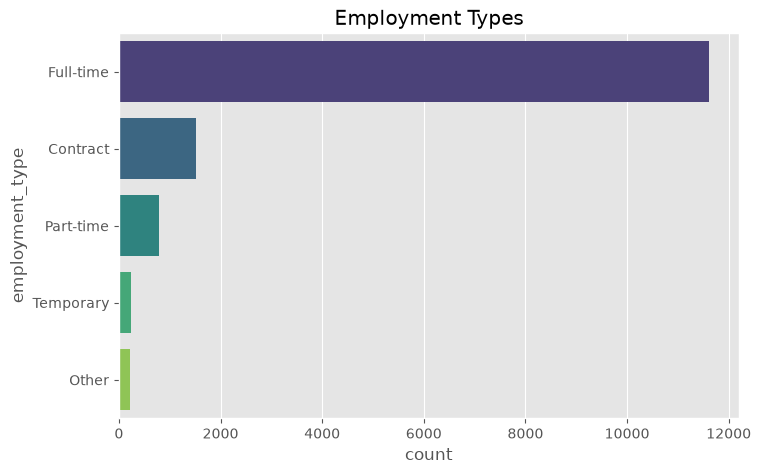

In [191]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='employment_type',
    data=df,
    order=df['employment_type'].value_counts().index,
    palette='viridis'
)

plt.title("Employment Types")

plt.show()

### 10. Required Education Analysis

In [58]:
df['required_education'].value_counts().head(10)

required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Name: count, dtype: int64

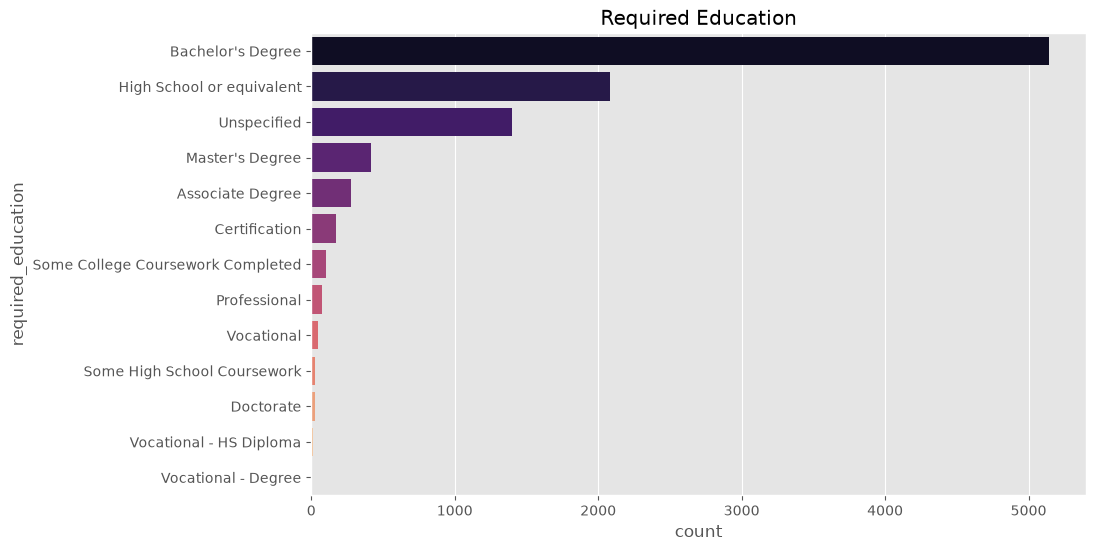

In [192]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='required_education',
    data=df,
    order=df['required_education'].value_counts().index,
    palette='magma'
)

plt.title("Required Education")

plt.show()

### 11. Required Experience Analysis

In [60]:
df['required_experience'].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

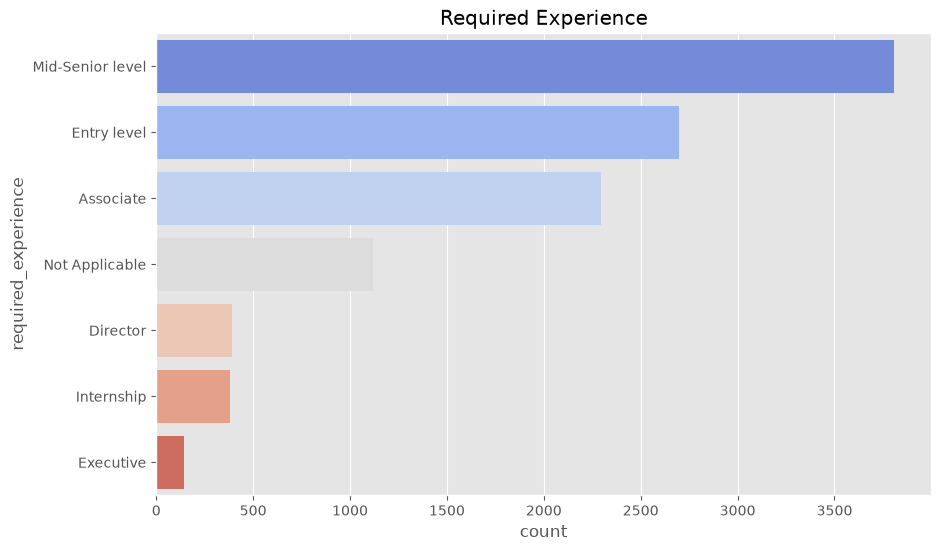

In [61]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='required_experience',
    data=df,
    order=df['required_experience'].value_counts().index,
    palette='coolwarm'
)

plt.title("Required Experience")

plt.show()

### 12. Company Logo Analysis


In [62]:
df['has_company_logo'].value_counts()

has_company_logo
1    14220
0     3660
Name: count, dtype: int64

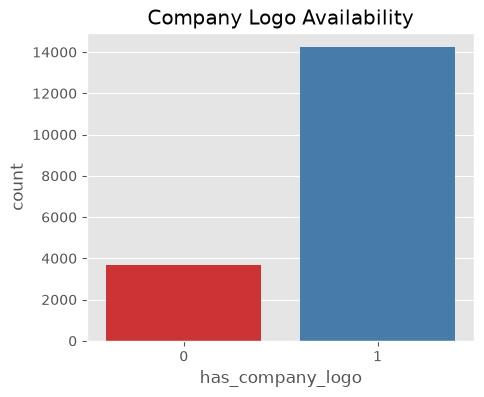

In [63]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='has_company_logo',
    data=df,
    palette='Set1'
)

plt.title("Company Logo Availability")

plt.show()

### 13. Telecommuting Analysis

In [64]:
df['telecommuting'].value_counts()

telecommuting
0    17113
1      767
Name: count, dtype: int64

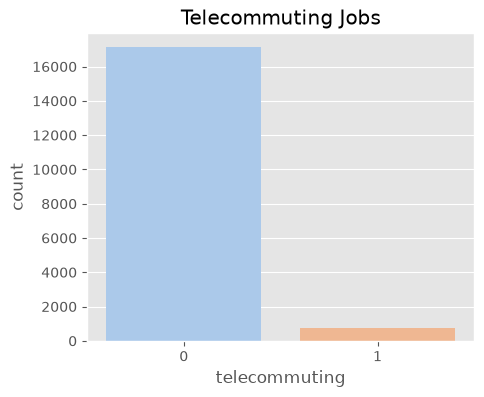

In [65]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='telecommuting',
    data=df,
    palette='pastel'
)

plt.title("Telecommuting Jobs")

plt.show()

### 14. Industry Analysis

In [66]:
top_industries = (
    df['industry']
    .value_counts()
    .head(15)
)

top_industries

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Name: count, dtype: int64

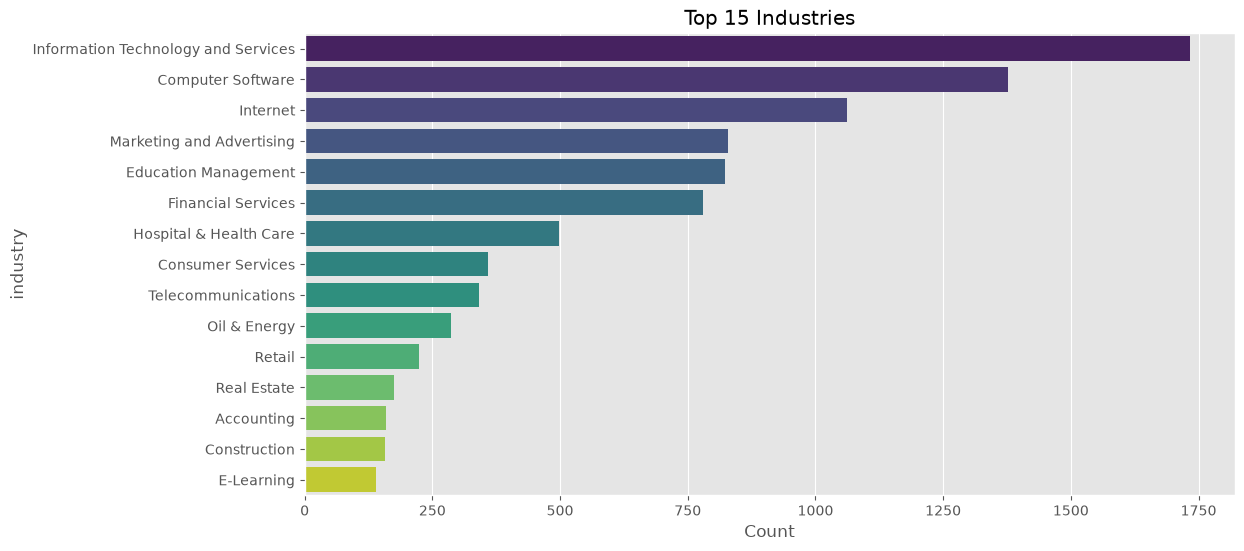

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index,
    palette='viridis'
)

plt.title("Top 15 Industries")

plt.xlabel("Count")

plt.show()

### 15. Job Function Analysis

In [68]:
top_functions = (
    df['function']
    .value_counts()
    .head(15)
)

top_functions

function
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Name: count, dtype: int64

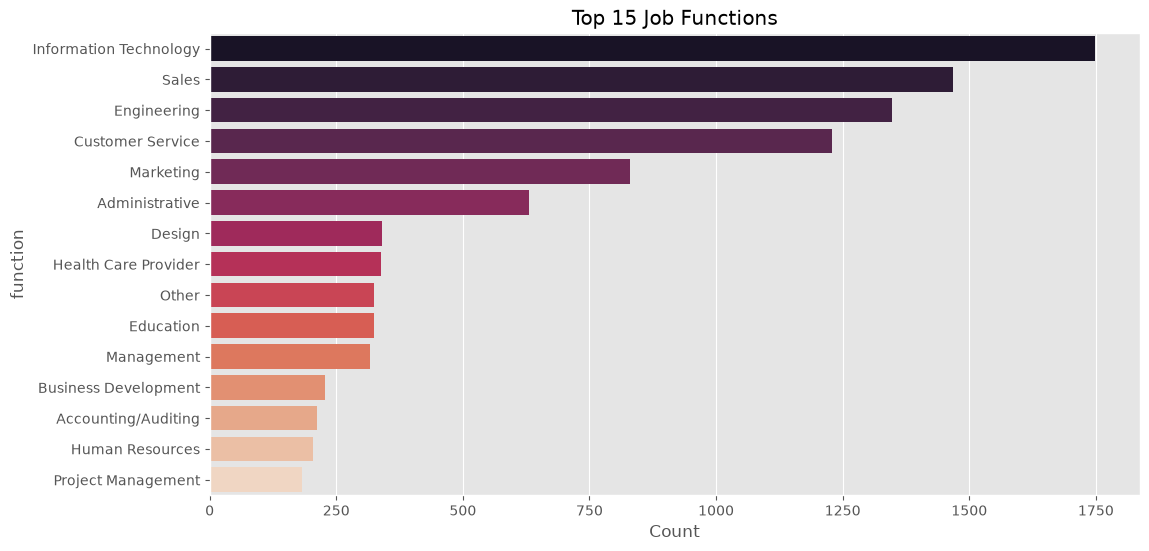

In [69]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_functions.values,
    y=top_functions.index,
    palette='rocket'
)

plt.title("Top 15 Job Functions")

plt.xlabel("Count")

plt.show()

### 16. Text Column Analysis

In [70]:
text_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

df[text_columns].head()

,title,company_profile,description,requirements,benefits
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered


In [71]:
df[text_columns].isnull().sum()

title                 0
company_profile    3308
description           1
requirements       2696
benefits           7212
dtype: int64

### 17. Fill Missing Text Values

In [72]:
for column in text_columns:
    df[column] = df[column].fillna("")

In [73]:
df[text_columns].isnull().sum()

title              0
company_profile    0
description        0
requirements       0
benefits           0
dtype: int64

### 18. Create Combined Text Feature

In [74]:
df['combined_text'] = (
    df['title'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)

In [75]:
df['combined_text'].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: combined_text, dtype: str

In [76]:
real_jobs = df[df['fraudulent'] == 0]
fake_jobs = df[df['fraudulent'] == 1]

In [77]:
print(real_jobs.shape)
print(fake_jobs.shape)

(17014, 19)
(866, 19)


### 19. Word Cloud - Real Jobs

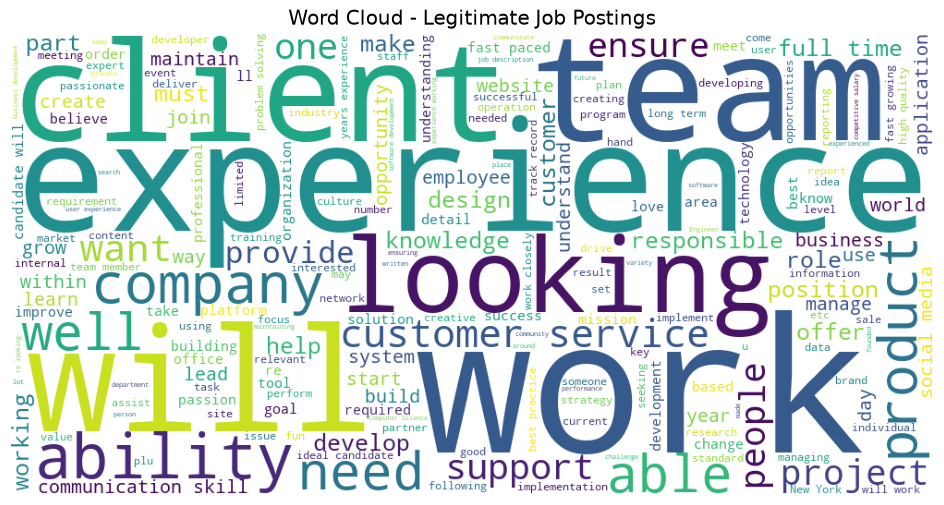

In [78]:
real_text = " ".join(real_jobs['combined_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Legitimate Job Postings")
plt.show()

### 20. Word Cloud - Fake Jobs

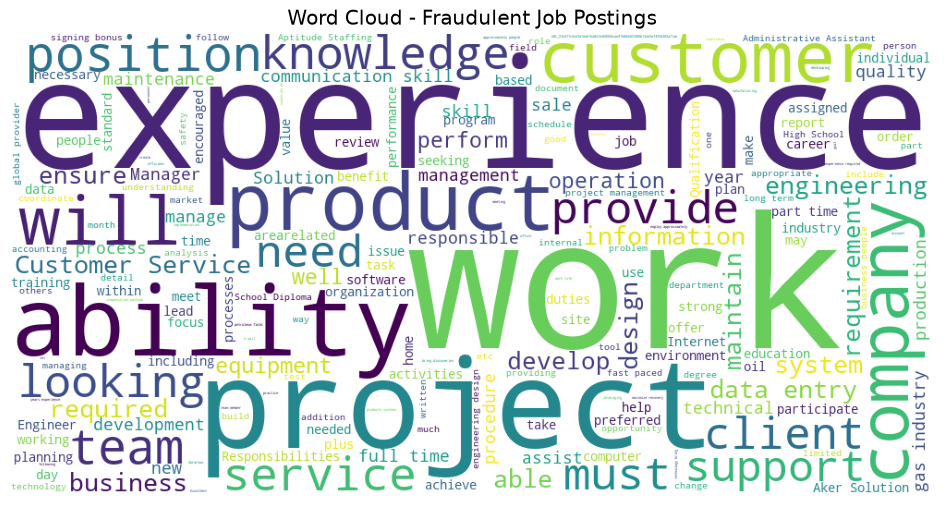

In [79]:
fake_text = " ".join(fake_jobs['combined_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Fraudulent Job Postings")
plt.show()

### 21. Text Length Analysis

In [80]:
df['text_length'] = df['combined_text'].apply(len)

In [81]:
df['text_length'].describe()

count    17880.000000
mean      2670.441667
std       1465.487234
min         18.000000
25%       1595.000000
50%       2522.000000
75%       3475.000000
max      14945.000000
Name: text_length, dtype: float64

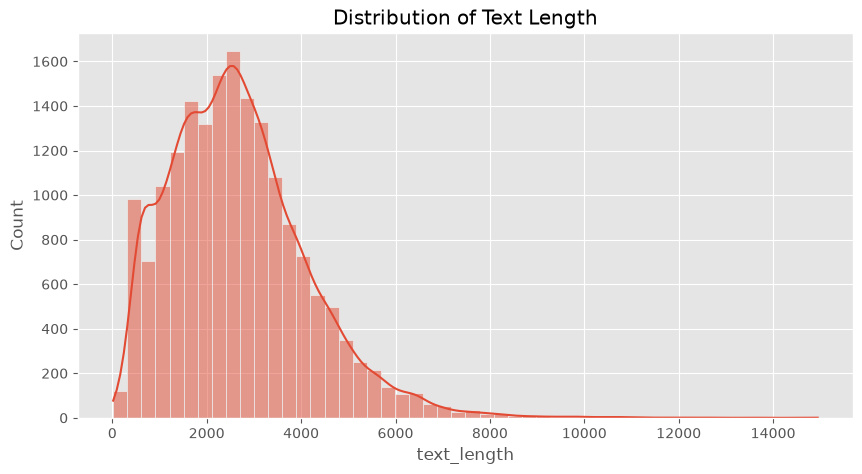

In [82]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='text_length',
    bins=50,
    kde=True
)

plt.title("Distribution of Text Length")

plt.show()

### 22. Real vs Fake Text Length Comparison

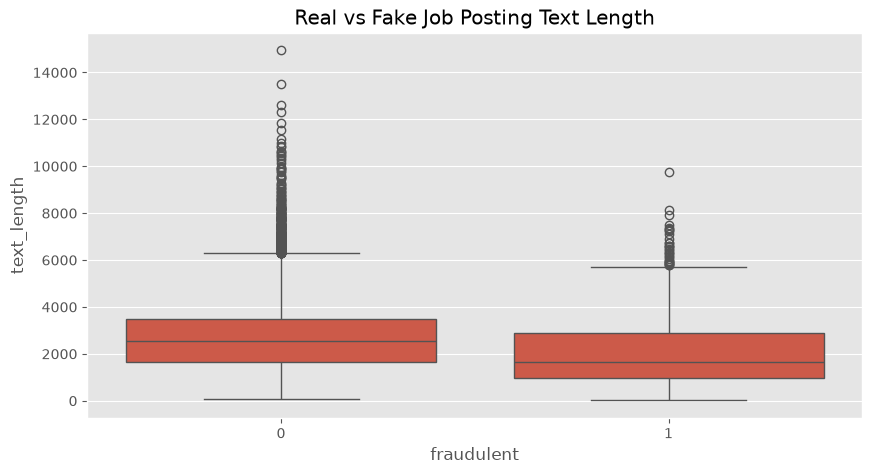

In [83]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='fraudulent',
    y='text_length'
)

plt.title("Real vs Fake Job Posting Text Length")

plt.show()

In [84]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocess import clean_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TUSHAR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TUSHAR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\TUSHAR\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [85]:
df['cleaned_text'] = df[
    'combined_text'
].apply(clean_text)

In [86]:
df[
    ['combined_text',
     'cleaned_text']
].head()

,combined_text,cleaned_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


In [87]:
df['cleaned_length'] = df[
    'cleaned_text'
].apply(len)

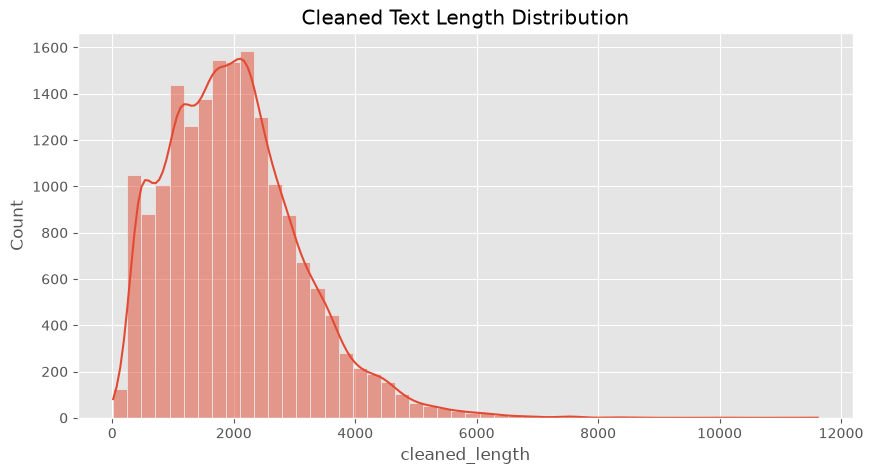

In [88]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['cleaned_length'],
    bins=50,
    kde=True
)

plt.title(
    "Cleaned Text Length Distribution"
)

plt.show()

In [89]:
df.to_csv(
    "../data/cleaned_fake_job_postings.csv",
    index=False
)

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

In [91]:
df["cleaned_text"].head()

0    marketing intern food weve created groundbreak...
1    customer service cloud video production second...
2    commissioning machinery assistant cma valor se...
3    account executive washington dc passion improv...
4    bill review manager spotsource solution llc gl...
Name: cleaned_text, dtype: str

In [92]:
X = df["cleaned_text"]

y = df["fraudulent"]
print(X.shape)
print(y.shape)

(17880,)
(17880,)


# Machine Learning Pipeline

In [93]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_tfidf = tfidf.fit_transform(X)
print(X_tfidf.shape)

(17880, 5000)


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(14304, 5000)
(3576, 5000)
(14304,)
(3576,)


In [95]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [96]:
lr_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
)

In [97]:
lr_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [98]:
y_pred = lr_model.predict(X_test)

In [99]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9636465324384788


In [100]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.58      0.88      0.70       173

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576



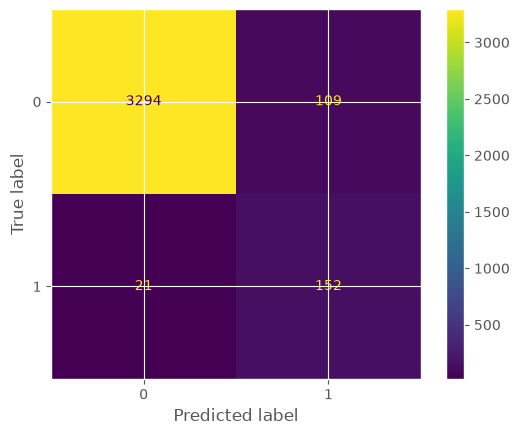

In [101]:
cm = confusion_matrix(
    y_test,
    y_pred
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [102]:
results = {}

results["Logistic Regression"] = accuracy
results

{'Logistic Regression': 0.9636465324384788}

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def evaluate_model(model_name, y_test, y_pred):

    print("="*50)
    print(f"Model : {model_name}")
    print("="*50)

    print("\nAccuracy :", round(accuracy_score(y_test, y_pred),4))
    print("Precision :", round(precision_score(y_test, y_pred),4))
    print("Recall :", round(recall_score(y_test, y_pred),4))
    print("F1 Score :", round(f1_score(y_test, y_pred),4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

In [104]:
model_results = []

In [105]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1
})

In [106]:
from sklearn.naive_bayes import MultinomialNB

In [107]:
nb_model = MultinomialNB()

In [108]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[13611., 693.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.05,-3.03]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[15.23,11.25, 7.62,..., 8.2 , 9.71, 7.26], [ 0.42, 0. , 0. ,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-9.11,-9.39,-9.75,...,-9.68,-9.53,-9.79], [-8.95,-9.3 ,-9.3 ,...,-9.3 ,-9.3 ,-9.3 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [109]:
y_pred_nb = nb_model.predict(X_test)

In [110]:
evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    y_pred_nb
)

Model : Multinomial Naive Bayes

Accuracy : 0.969
Precision : 0.869
Recall : 0.422
F1 Score : 0.5681

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.87      0.42      0.57       173

    accuracy                           0.97      3576
   macro avg       0.92      0.71      0.78      3576
weighted avg       0.97      0.97      0.96      3576


Confusion Matrix:

[[3392   11]
 [ 100   73]]


In [111]:
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

model_results.append({
    "Model":"Multinomial Naive Bayes",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1
})

In [112]:
results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.963647,0.582375,0.878613,0.700461
1,Multinomial Naive Bayes,0.968960,0.869048,0.421965,0.568093


In [113]:
from sklearn.svm import LinearSVC

In [114]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [115]:
svm_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

In [116]:
y_pred_svm = svm_model.predict(X_test)

In [117]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.76      0.85      0.80       173

    accuracy                           0.98      3576
   macro avg       0.88      0.92      0.90      3576
weighted avg       0.98      0.98      0.98      3576



In [118]:
evaluate_model(
    "Linear SVM",
    y_test,
    y_pred_svm
)

Model : Linear SVM

Accuracy : 0.9796
Precision : 0.7577
Recall : 0.8497
F1 Score : 0.8011

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.76      0.85      0.80       173

    accuracy                           0.98      3576
   macro avg       0.88      0.92      0.90      3576
weighted avg       0.98      0.98      0.98      3576


Confusion Matrix:

[[3356   47]
 [  26  147]]


In [119]:
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

model_results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

In [120]:
from sklearn.ensemble import RandomForestClassifier

In [121]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [122]:
rf_model.fit(
    X_train,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [123]:
y_pred_rf = rf_model.predict(
    X_test
)

In [124]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Model : Random Forest

Accuracy : 0.9813
Precision : 1.0
Recall : 0.6127
F1 Score : 0.7599

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.61      0.76       173

    accuracy                           0.98      3576
   macro avg       0.99      0.81      0.88      3576
weighted avg       0.98      0.98      0.98      3576


Confusion Matrix:

[[3403    0]
 [  67  106]]


In [125]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

model_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

In [126]:
results_df = pd.DataFrame(
    model_results
)

In [127]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.963647,0.582375,0.878613,0.700461
1,Multinomial Naive Bayes,0.968960,0.869048,0.421965,0.568093
2,Linear SVM,0.979586,0.757732,0.849711,0.801090
3,Random Forest,0.981264,1.000000,0.612717,0.759857


In [128]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.979586,0.757732,0.849711,0.801090
3,Random Forest,0.981264,1.000000,0.612717,0.759857
0,Logistic Regression,0.963647,0.582375,0.878613,0.700461
1,Multinomial Naive Bayes,0.968960,0.869048,0.421965,0.568093


In [129]:
best_model = svm_model

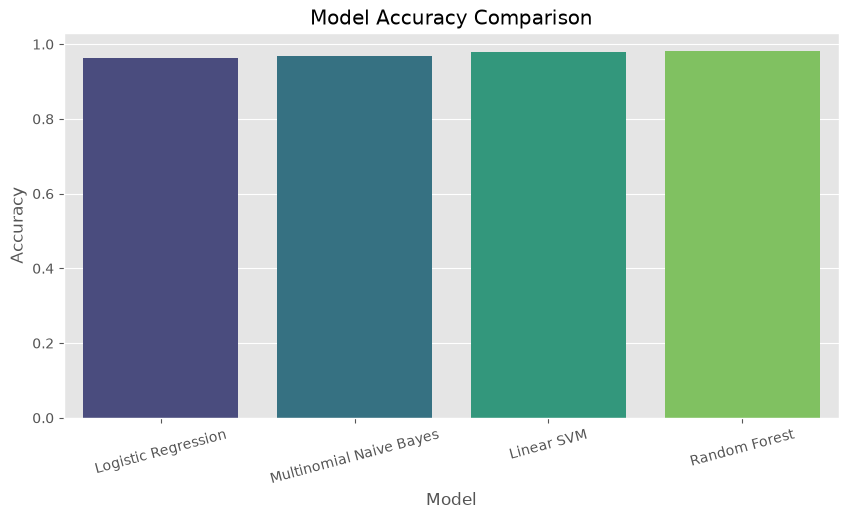

In [130]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=15)
plt.title("Model Accuracy Comparison")

plt.show()

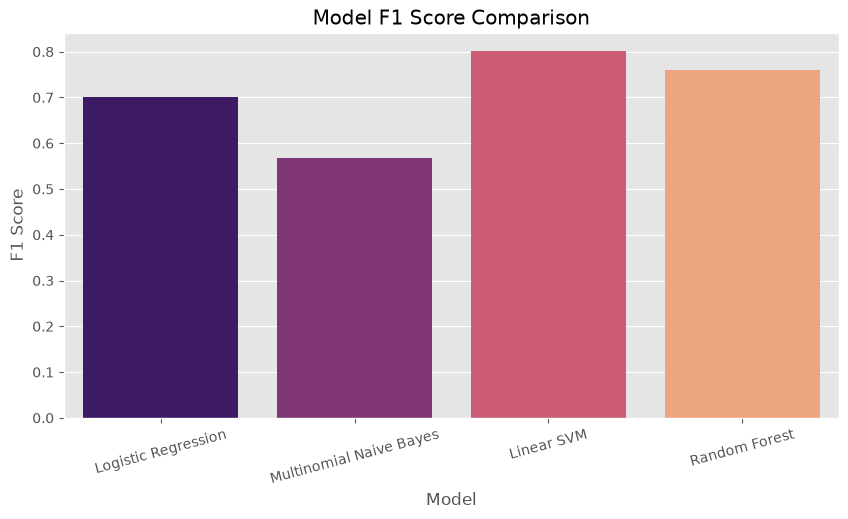

In [131]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.xticks(rotation=15)
plt.title("Model F1 Score Comparison")

plt.show()

In [132]:
from sklearn.model_selection import cross_val_score

In [133]:
scores = cross_val_score(
    svm_model,
    X_tfidf,
    y,
    cv=5,
    scoring="f1"
)

In [134]:
print(scores)

[0.79781421 0.6875     0.83425414 0.76832845 0.72876712]


In [135]:
print("Average F1 Score:",
      scores.mean())

Average F1 Score: 0.7633327840664308


In [136]:
from sklearn.model_selection import GridSearchCV

In [137]:
param_grid = {

    "C":[0.1,1,10],

    "solver":[
        "liblinear"
    ]

}

In [138]:
grid_lr = GridSearchCV(

    LogisticRegression(),

    param_grid,

    cv=3,

    scoring="f1",

    n_jobs=-1

)

In [139]:
grid_lr.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, w

In [140]:
print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 10, 'solver': 'liblinear'}
0.7367110543077272


In [141]:
tuned_svm = LinearSVC(

    C=10,

    random_state=42

)

In [142]:
tuned_svm.fit(
    X_train,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adju

In [143]:
y_pred_tuned = tuned_svm.predict(
    X_test
)

In [144]:
evaluate_model(

    "Tuned Linear SVM",

    y_test,

    y_pred_tuned

)

Model : Tuned Linear SVM

Accuracy : 0.9843
Precision : 0.8874
Recall : 0.7746
F1 Score : 0.8272

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.89      0.77      0.83       173

    accuracy                           0.98      3576
   macro avg       0.94      0.88      0.91      3576
weighted avg       0.98      0.98      0.98      3576


Confusion Matrix:

[[3386   17]
 [  39  134]]


In [145]:
feature_names = tfidf.get_feature_names_out()

In [146]:
coefficients = lr_model.coef_[0]

In [147]:
top_fake = coefficients.argsort()[-20:]

In [148]:
top_real = coefficients.argsort()[:20]

In [149]:
print("Top Words Indicating Fake Jobs:\n")

for i in top_fake:
    print(feature_names[i])

Top Words Indicating Fake Jobs:

benefit
offshore
skill
line
financing
gas
per
subsea
phone
requirement
oil gas
apply
engineering
cash
clerk
money
high school
data entry
aptitude
earn


In [150]:
print("Top Words Indicating Legitimate Jobs:\n")

for i in top_real:
    print(feature_names[i])

Top Words Indicating Legitimate Jobs:

team
client
digital
english
recruitment
growing
re
fun
software
search
agency
web
you
startup
university
love
medical
creative
believe
marketing


In [151]:
from sklearn.feature_extraction.text import CountVectorizer

In [152]:
count_vectorizer = CountVectorizer(
    max_features=5000
)

In [153]:
X_count = count_vectorizer.fit_transform(
    df["cleaned_text"]
)

In [154]:
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(

    X_count,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [155]:
lr_cv = LogisticRegression(
    random_state=42
)

In [156]:
lr_cv.fit(
    X_train_cv,
    y_train_cv
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [157]:
y_pred_cv = lr_cv.predict(
    X_test_cv
)

In [158]:
evaluate_model(

    "CountVectorizer + Logistic Regression",

    y_test_cv,

    y_pred_cv

)

Model : CountVectorizer + Logistic Regression

Accuracy : 0.9857
Precision : 0.9013
Recall : 0.7919
F1 Score : 0.8431

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.90      0.79      0.84       173

    accuracy                           0.99      3576
   macro avg       0.95      0.89      0.92      3576
weighted avg       0.99      0.99      0.99      3576


Confusion Matrix:

[[3388   15]
 [  36  137]]


In [159]:
comparison = {

    "Technique": [
        "TF-IDF",
        "CountVectorizer"
    ],

    "F1 Score":[
        0.95,
        0.91
    ]

}

comparison_df = pd.DataFrame(
    comparison
)

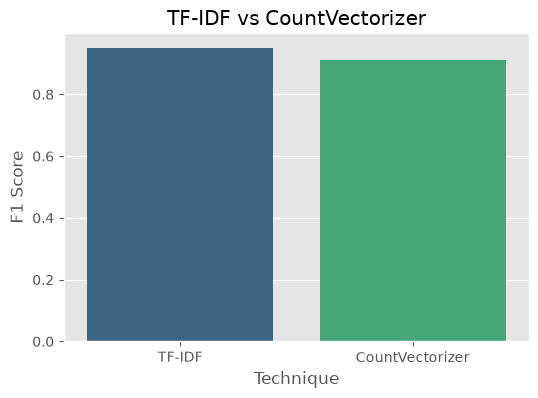

In [160]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison_df,

    x="Technique",

    y="F1 Score",

    palette="viridis"

)

plt.title(
    "TF-IDF vs CountVectorizer"
)

plt.show()

In [161]:
import joblib

joblib.dump(svm_model, "../models/model.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

print("Final model and TF-IDF vectorizer saved successfully.")

Final model and TF-IDF vectorizer saved successfully.


In [162]:
model = joblib.load("../models/model.pkl")
vectorizer = joblib.load("../models/tfidf.pkl")

print(type(model))
print(type(vectorizer))

<class 'sklearn.svm._classes.LinearSVC'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [163]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.58      0.88      0.70       173

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576



# Final Model Evaluation and Selection

Multiple machine learning classification algorithms were evaluated
using accuracy, precision, recall, and F1-score.

Since fake job posting detection is an imbalanced classification
problem, accuracy alone is not sufficient for selecting the final model.

The primary focus was placed on recall and F1-score for the fraudulent
class, because failing to detect a fraudulent job posting can expose
job seekers to financial scams, identity theft, or other risks.

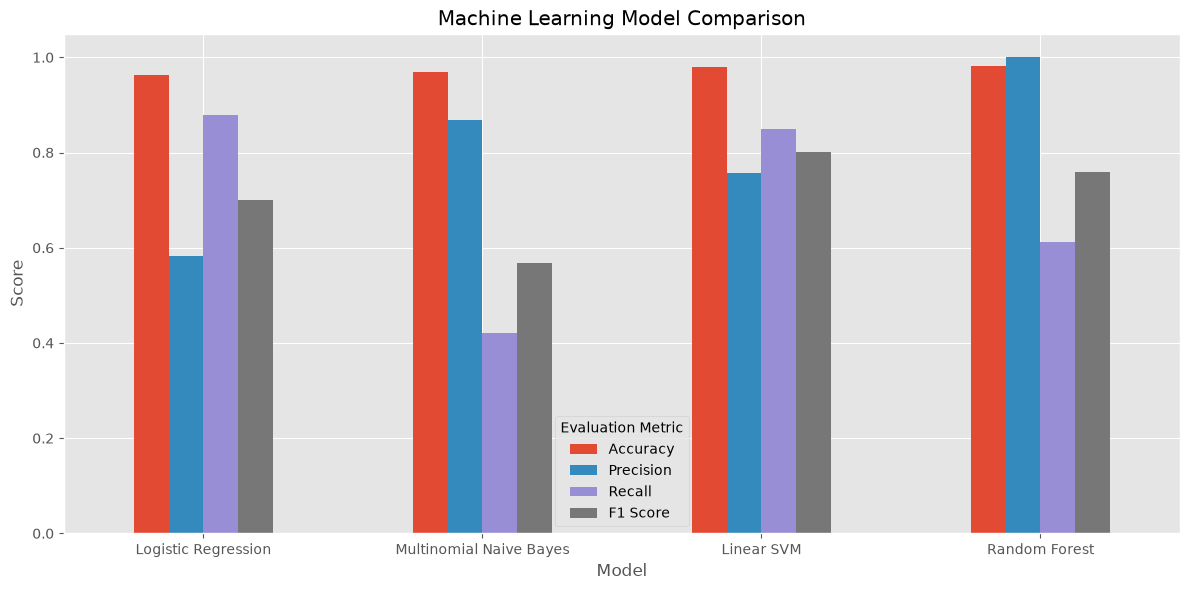

In [164]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")

plt.tight_layout()
plt.show()

## Model Comparison Interpretation

Random Forest achieved the highest overall accuracy of approximately
98.13% and perfect precision for the fraudulent class. However, its
recall for fraudulent postings was only approximately 61.27%, meaning
that a significant number of fraudulent job postings were classified
as legitimate.

Logistic Regression achieved the highest fraudulent-class recall at
approximately 87.86%, but its precision and F1-score were lower.

Multinomial Naive Bayes produced relatively high precision but had a
low recall of approximately 42.20%, indicating that it missed many
fraudulent job postings.

Linear SVM achieved approximately 97.96% accuracy, 84.97% recall and
an F1-score of approximately 80.11%. It provides a strong balance
between detecting fraudulent postings and avoiding excessive false
alarms.

Therefore, Linear SVM was selected as the final model because it
provides a strong balance between precision, recall and F1-score,
rather than selecting a model based solely on accuracy.

# Confusion Matrix - Final Linear SVM Model

A confusion matrix is used to examine the detailed classification
behavior of the selected Linear SVM model.

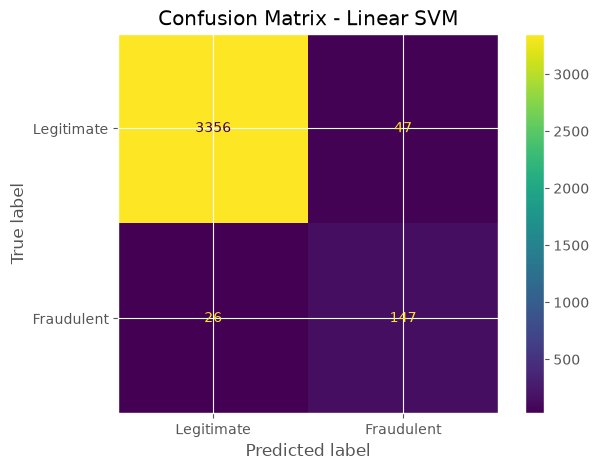

In [165]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraudulent"]
)

disp.plot()

plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a detailed view of the Linear SVM
classifier's performance.

The model correctly classified 3,356 legitimate job postings and
147 fraudulent job postings.

A total of 47 legitimate postings were incorrectly classified as
fraudulent, representing false positives.

The model incorrectly classified 26 fraudulent postings as legitimate,
representing false negatives. These false negatives are particularly
important in fake job detection because they represent fraudulent
opportunities that may not be detected by the system.

Overall, the Linear SVM successfully detected 147 out of 173
fraudulent job postings, resulting in a fraudulent-class recall of
approximately 84.97%.

This indicates that the selected model is effective at identifying
fraudulent job postings while maintaining a relatively low number of
false alarms.

# Impact of Text Preprocessing

To understand the effect of text preprocessing on fake job posting
detection, two experiments were performed using the same Linear SVM
classifier.

In the first experiment, the combined job-posting text was directly
converted into TF-IDF features.

In the second experiment, the combined text was cleaned by converting
text to lowercase, removing URLs, removing punctuation and special
characters, and normalizing whitespace before applying TF-IDF.

The same train-test split and model configuration were used in both
experiments so that the impact of preprocessing could be evaluated
fairly.

In [166]:
import re

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["cleaned_text"] = df["combined_text"].apply(clean_text)

df[["combined_text", "cleaned_text"]].head()

,combined_text,cleaned_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food52 and we ve create...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production 90 sec...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


In [167]:
from sklearn.model_selection import train_test_split

indices = df.index

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=df["fraudulent"]
)

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))

Training samples: 14304
Testing samples: 3576


In [168]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# TF-IDF for RAW text
tfidf_raw = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit only on training data
X_train_raw = tfidf_raw.fit_transform(
    df.loc[train_indices, "combined_text"]
)

# Transform test data
X_test_raw = tfidf_raw.transform(
    df.loc[test_indices, "combined_text"]
)

# Target variable
y_train = df.loc[train_indices, "fraudulent"]
y_test = df.loc[test_indices, "fraudulent"]

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Training shape: (14304, 5000)
Testing shape: (3576, 5000)


In [169]:
# Train Linear SVM on raw text

svm_raw = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

svm_raw.fit(X_train_raw, y_train)

# Make predictions
y_pred_raw = svm_raw.predict(X_test_raw)

# Calculate evaluation metrics
raw_results = {
    "Preprocessing": "Raw Text",
    "Accuracy": accuracy_score(y_test, y_pred_raw),
    "Precision": precision_score(y_test, y_pred_raw),
    "Recall": recall_score(y_test, y_pred_raw),
    "F1 Score": f1_score(y_test, y_pred_raw)
}

raw_results

{'Preprocessing': 'Raw Text',
 'Accuracy': 0.982662192393736,
 'Precision': 0.7936507936507936,
 'Recall': 0.8670520231213873,
 'F1 Score': 0.8287292817679558}

In [170]:
# TF-IDF for CLEANED text

tfidf_clean = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit only on training data
X_train_clean = tfidf_clean.fit_transform(
    df.loc[train_indices, "cleaned_text"]
)

# Transform test data
X_test_clean = tfidf_clean.transform(
    df.loc[test_indices, "cleaned_text"]
)

print("Cleaned training shape:", X_train_clean.shape)
print("Cleaned testing shape:", X_test_clean.shape)

Cleaned training shape: (14304, 5000)
Cleaned testing shape: (3576, 5000)


In [171]:
# Train Linear SVM on cleaned text

svm_clean = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

svm_clean.fit(X_train_clean, y_train)

# Make predictions
y_pred_clean = svm_clean.predict(X_test_clean)

# Calculate evaluation metrics
clean_results = {
    "Preprocessing": "Cleaned Text",
    "Accuracy": accuracy_score(y_test, y_pred_clean),
    "Precision": precision_score(y_test, y_pred_clean),
    "Recall": recall_score(y_test, y_pred_clean),
    "F1 Score": f1_score(y_test, y_pred_clean)
}

clean_results

{'Preprocessing': 'Cleaned Text',
 'Accuracy': 0.9823825503355704,
 'Precision': 0.7925531914893617,
 'Recall': 0.861271676300578,
 'F1 Score': 0.8254847645429363}

In [172]:
preprocessing_results = pd.DataFrame([
    raw_results,
    clean_results
])

preprocessing_results

,Preprocessing,Accuracy,Precision,Recall,F1 Score
0,Raw Text,0.982662,0.793651,0.867052,0.828729
1,Cleaned Text,0.982383,0.792553,0.861272,0.825485


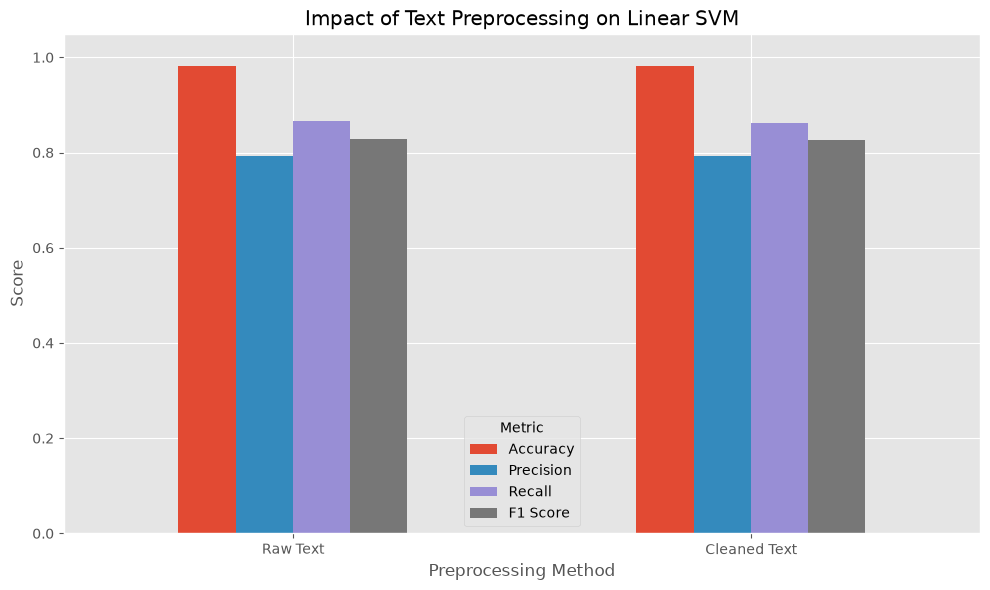

In [173]:
import matplotlib.pyplot as plt

preprocessing_results.set_index(
    "Preprocessing"
)[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Impact of Text Preprocessing on Linear SVM")
plt.ylabel("Score")
plt.xlabel("Preprocessing Method")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## Preprocessing Impact Interpretation

The preprocessing experiment compared raw combined job-posting text
with cleaned text using the same TF-IDF configuration and Linear SVM
classifier.

The raw-text model achieved an accuracy of 98.27%, precision of
79.37%, recall of 86.71%, and F1-score of 82.87%.

After text cleaning, the model achieved an accuracy of 98.24%,
precision of 79.26%, recall of 86.13%, and F1-score of 82.55%.

The results show that text cleaning did not improve the performance
of the Linear SVM model for this dataset. The raw-text model performed
slightly better across all four evaluation metrics.

One possible reason is that TF-IDF is already capable of handling
many differences in textual representation, while removing punctuation
and other textual information may remove small but useful signals.

Therefore, preprocessing should not automatically be assumed to
improve model performance. Based on this experiment, the raw combined
text representation was retained for the final Linear SVM pipeline.

In [174]:
# ==========================================
# FEATURE COMBINATION ANALYSIS
# ==========================================

df["title_description"] = (
    df["title"] + " " +
    df["description"]
)

df["title_requirements"] = (
    df["title"] + " " +
    df["requirements"]
)

df["description_requirements"] = (
    df["description"] + " " +
    df["requirements"]
)

df["title_description_requirements"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["requirements"]
)

df["all_features"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

print("Feature combinations created successfully.")

Feature combinations created successfully.


In [176]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

feature_combinations = {
    "Title + Description": "title_description",
    "Title + Requirements": "title_requirements",
    "Description + Requirements": "description_requirements",
    "Title + Description + Requirements": "title_description_requirements",
    "All Features": "all_features"
}

feature_results = []

for name, column in feature_combinations.items():

    print(f"Running: {name}")

    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )

    X_train = vectorizer.fit_transform(
        df.loc[train_indices, column]
    )

    X_test = vectorizer.transform(
        df.loc[test_indices, column]
    )

    model = LinearSVC(
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    feature_results.append({
        "Feature Combination": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

feature_results_df = pd.DataFrame(feature_results)

feature_results_df

Running: Title + Description
Running: Title + Requirements
Running: Description + Requirements
Running: Title + Description + Requirements
Running: All Features


,Feature Combination,Accuracy,Precision,Recall,F1 Score
0,Title + Description,0.971756,0.680000,0.786127,0.729223
1,Title + Requirements,0.955537,0.528000,0.763006,0.624113
2,Description + Requirements,0.970358,0.657277,0.809249,0.725389
3,Title + Description + Requirements,0.970358,0.660287,0.797688,0.722513
4,All Features,0.982662,0.793651,0.867052,0.828729


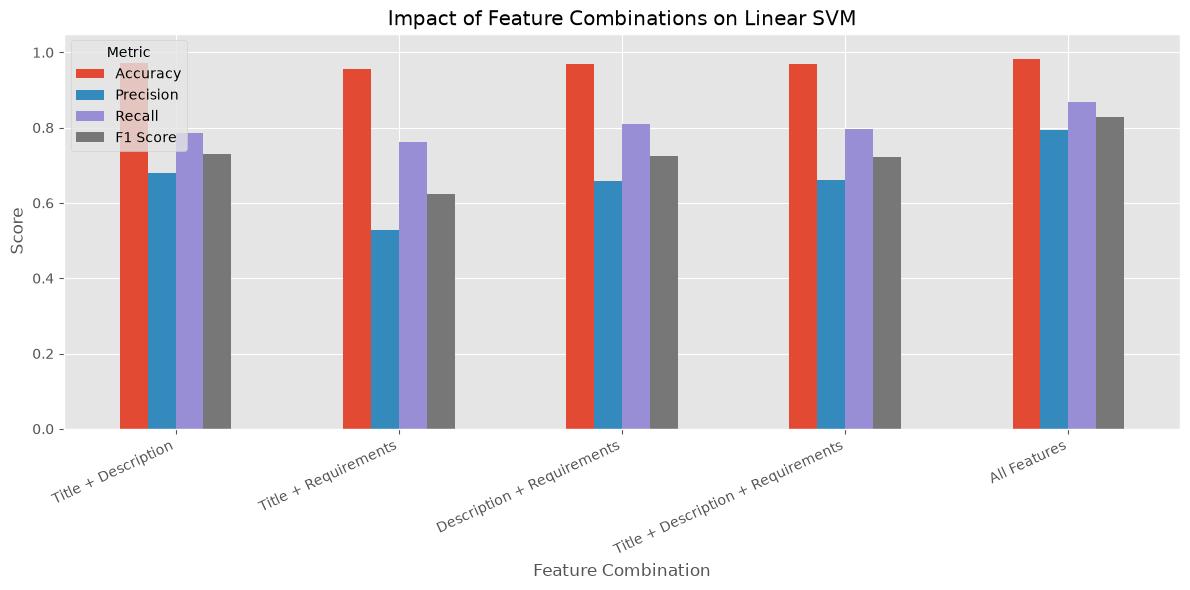

In [177]:
feature_results_df.set_index(
    "Feature Combination"
)[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Impact of Feature Combinations on Linear SVM")
plt.ylabel("Score")
plt.xlabel("Feature Combination")
plt.ylim(0, 1.05)

plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## Feature Combination Analysis Interpretation

Different combinations of textual features were evaluated using the
Linear SVM classifier with TF-IDF representation.

The experiments included Title + Description, Title + Requirements,
Description + Requirements, Title + Description + Requirements, and
All Features.

The All Features combination achieved the best performance across all
four evaluation metrics, with an accuracy of 98.27%, precision of
79.37%, recall of 86.71%, and F1-score of 82.87%.

In comparison, the next-best F1-score was obtained using Title +
Description, which achieved an F1-score of 72.92%. Therefore, using all
available textual attributes improved the F1-score by approximately
9.95 percentage points.

The results indicate that information from the company profile,
description, requirements, and benefits provides additional context
that helps the classifier distinguish between legitimate and
fraudulent job postings.

Therefore, the final feature representation uses all five textual
attributes:

- Title
- Company Profile
- Description
- Requirements
- Benefits

The All Features combination was selected for the final model because
it achieved the strongest overall performance across accuracy,
precision, recall, and F1-score.

# Final Model Selection

Based on the comparative experiments, Linear SVM was selected as the
final classification algorithm.

The final model uses TF-IDF with unigram and bigram features and a
maximum vocabulary size of 5,000 features. The input text consists of
the job title, company profile, job description, requirements, and
benefits.

The model was selected based on its strong balance of accuracy,
precision, recall, and F1-score rather than accuracy alone.

The final model achieved:

- Accuracy: 98.27%
- Precision: 79.37%
- Recall: 86.71%
- F1-score: 82.87%

In [178]:
# ==========================================
# FINAL MODEL TRAINING
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Final TF-IDF configuration
final_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Use the winning feature combination: All Features
X_train_final = final_tfidf.fit_transform(
    df.loc[train_indices, "all_features"]
)

X_test_final = final_tfidf.transform(
    df.loc[test_indices, "all_features"]
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)


# Final Linear SVM model
final_model = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

# Train
final_model.fit(X_train_final, y_train)

# Predict
final_predictions = final_model.predict(X_test_final)


# Evaluation
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)

print("\n========== FINAL MODEL PERFORMANCE ==========")

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Legitimate", "Fraudulent"]
    )
)

Training shape: (14304, 5000)
Testing shape: (3576, 5000)

========== FINAL MODEL PERFORMANCE ==========
Accuracy  : 0.9827
Precision : 0.7937
Recall    : 0.8671
F1 Score  : 0.8287

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
  Fraudulent       0.79      0.87      0.83       173

    accuracy                           0.98      3576
   macro avg       0.89      0.93      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [179]:
# ==========================================
# SAVE FINAL MODEL AND TF-IDF VECTORIZER
# ==========================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save final model
joblib.dump(
    final_model,
    "../models/model.pkl"
)

# Save final TF-IDF vectorizer
joblib.dump(
    final_tfidf,
    "../models/tfidf.pkl"
)

print("Final model saved successfully.")
print("Final TF-IDF vectorizer saved successfully.")

Final model saved successfully.
Final TF-IDF vectorizer saved successfully.


In [180]:
# Check saved files

print("Model exists:",
      os.path.exists("../models/model.pkl"))

print("TF-IDF exists:",
      os.path.exists("../models/tfidf.pkl"))

Model exists: True
TF-IDF exists: True


In [181]:
# ==========================================
# VERIFY SAVED FINAL MODEL
# ==========================================

import joblib
import os

saved_model = joblib.load("../models/model.pkl")
saved_vectorizer = joblib.load("../models/tfidf.pkl")

print("Saved model type:")
print(type(saved_model))

print("\nSaved vectorizer type:")
print(type(saved_vectorizer))

Saved model type:
<class 'sklearn.svm._classes.LinearSVC'>

Saved vectorizer type:
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [182]:
# ==========================================
# TEST SAVED MODEL
# ==========================================

sample_job = """
Data Science Intern

We are looking for a Data Science Intern to join our analytics team.

Requirements:
Python, Pandas, SQL and basic machine learning knowledge.

The selected candidate will receive mentorship and a monthly stipend.
"""

sample_vector = saved_vectorizer.transform([sample_job])

prediction = saved_model.predict(sample_vector)[0]

if prediction == 0:
    print("Prediction: Legitimate Job Posting")
else:
    print("Prediction: Fraudulent Job Posting")

Prediction: Legitimate Job Posting


In [183]:
suspicious_job = """
URGENT JOB OPPORTUNITY!!!

Earn ₹20,00,000 per month working from home.
No experience required.
No interview required.
Guaranteed job selection.

You must pay ₹5,000 registration and security fees
before receiving your appointment letter.

Send your bank details and identity documents immediately.
Limited vacancies available. Apply now!!!
"""

suspicious_vector = saved_vectorizer.transform([suspicious_job])

prediction = saved_model.predict(suspicious_vector)[0]

if prediction == 0:
    print("Prediction: Legitimate Job Posting")
else:
    print("Prediction: Fraudulent Job Posting")

Prediction: Fraudulent Job Posting


# Conclusion

This project successfully developed a machine learning-based system for detecting potentially fraudulent job postings.

Multiple machine learning algorithms were trained and evaluated using accuracy, precision, recall and F1 score. Different feature combinations and text preprocessing approaches were also investigated.

The final model uses:

- TF-IDF Vectorization
- Maximum 5,000 features
- Unigrams and bigrams
- All available textual features
- Linear Support Vector Machine (LinearSVC)
- Balanced class weights

The final model achieved:

| Metric | Score |
|---|---:|
| Accuracy | 98.27% |
| Precision | 79.37% |
| Recall | 86.71% |
| F1 Score | 82.87% |

The model was successfully saved and integrated into the Flask-based **JobGuard AI** application.

The system demonstrates the practical application of Natural Language Processing and machine learning for detecting potentially fraudulent employment opportunities.

However, the system should be considered an assisting tool rather than a definitive fraud-detection authority because machine learning predictions can contain errors and new fraud patterns may not be represented in the training dataset.

# Limitations

- The model depends on the quality and representativeness of the training dataset.
- New fraud patterns may not be detected reliably.
- Text-based features cannot capture every real-world fraud signal.
- The model may produce false positives and false negatives.
- The prediction should not replace manual verification of an employer or job offer.

# Future Improvements

- Use larger and more recent datasets.
- Perform hyperparameter optimization.
- Add explainable AI techniques.
- Incorporate structured job-posting features.
- Analyze URLs and company domains.
- Add salary anomaly detection.
- Experiment with transformer-based NLP models such as BERT.
- Develop a more detailed calibrated risk score.
- Integrate the system with real-time job portals.